# 04 - Explainability and Segments (Maximum-Detail)

This notebook is the final analytical step before the FastAPI service. It consumes:
- **Notebook 01 — EDA**: high-risk segments (Month-to-month + Fiber Optic + Electronic Check), revenue-at-risk framing, and 26.5% positive class.
- **Notebook 02 — Preprocessing diagnostics**: validated leakage-safe pipeline producing the design matrix.
- **Notebook 03 — Model benchmark**: persisted `models/champion_pipeline.joblib`, cost-optimal threshold, and the leaderboard.

## Why explainability matters here
1. **Trust** — A retention team will not act on black-box scores. We need *which* features push customers toward churn.
2. **Action** — Each SHAP-positive feature should map to a retention lever (contract upgrade, payment-method nudge, fiber stability outreach).
3. **Risk control** — A model can have great test AUC but discriminate against a protected segment. We audit per-segment behaviour at the **production threshold**.
4. **Explanation duality** — We compute explanations on **both** a linear champion and a non-linear auxiliary model (XGBoost) so we can decide whether non-linear interactions justify a future model swap.

## Section map
1. Setup, load champion, rebuild splits
2. Champion performance recap at the production (cost-optimal) threshold
3. Logistic regression coefficient interpretation (signed contributions)
4. Model-agnostic permutation importance
5. Global SHAP — linear champion (beeswarm + bar)
6. Auxiliary tree model + Tree SHAP for non-linear comparison
7. SHAP dependence plots for top features
8. SHAP interaction analysis (XGBoost)
9. Local explanations — 4 customer archetypes (TP, FP, FN, borderline)
10. Segment risk heatmap (Contract × InternetService × PaymentMethod)
11. Top-decile retention cohort profiling
12. Persona clustering on top-risk customers
13. What-if counterfactuals (contract / payment / autopay levers)
14. Fairness audit at production threshold
15. Retention playbook and hand-off

In [1]:
import sys
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocessing import (
    TARGET_COLUMN,
    build_preprocessor,
    engineer_features,
    load_data,
    split_features_target,
)

DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'telco.csv'
MODELS_DIR = REPO_ROOT / 'models'
RANDOM_STATE = 42

champion_pipeline = joblib.load(MODELS_DIR / 'champion_pipeline.joblib')
with open(MODELS_DIR / 'champion_metadata.json', 'r', encoding='utf-8') as fp:
    champion_meta = json.load(fp)
with open(MODELS_DIR / 'decision_threshold.json', 'r', encoding='utf-8') as fp:
    threshold_meta = json.load(fp)

PROD_THRESHOLD = float(threshold_meta['threshold'])
print(f"Champion model       : {champion_meta['champion_model']}")
print(f"Test ROC-AUC         : {champion_meta['selection_score']:.4f}")
print(f"Test PR-AUC          : {champion_meta['test_pr_auc']:.4f}")
print(f"Production threshold : {PROD_THRESHOLD:.3f} (optimization={threshold_meta['optimization']})")

df_raw = load_data(str(DATA_PATH))
df_engineered = engineer_features(df_raw)
prepared = split_features_target(df_engineered)
X, y = prepared.X, prepared.y
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y,
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp,
)
print(f"\nTrain={len(X_train)} | Valid={len(X_valid)} | Test={len(X_test)}")

Champion model       : logistic_regression
Test ROC-AUC         : 0.8477
Test PR-AUC          : 0.6832
Production threshold : 0.120 (optimization=cost-min)

Train=4930 | Valid=1056 | Test=1057


## 1) Champion Performance at the Production Threshold

The leaderboard in notebook 03 ranked by ROC-AUC at the default 0.5 threshold. Here we recap the **deployed** behaviour: predictions thresholded at the cost-optimal cutoff persisted to `decision_threshold.json`.

,view,accuracy,precision,recall,f1,roc_auc,positive_rate
0,default 0.50,0.7521,0.5231,0.7651,0.6214,0.8477,0.3888
1,prod 0.12,0.5251,0.3571,0.9822,0.5237,0.8477,0.7313


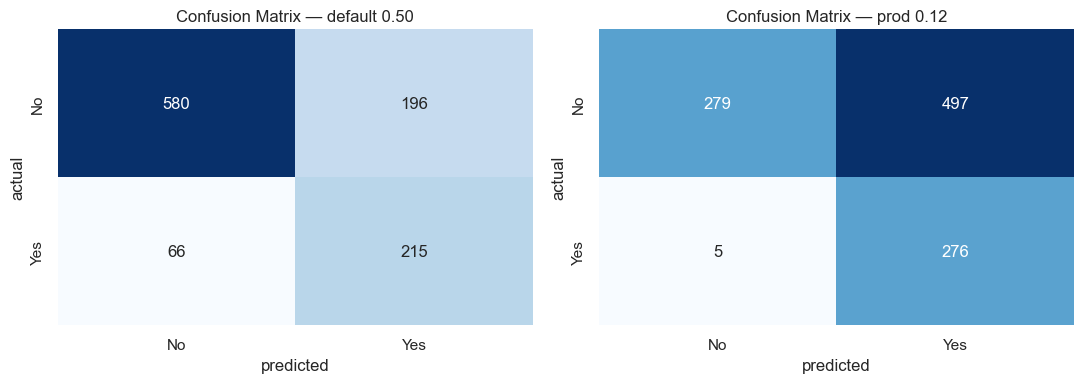


At the production threshold the champion flags 773 of 1057 test customers (73.1%) and captures 276 of 281 actual churners (98.2% recall).


In [2]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)

p_test = champion_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (p_test >= 0.5).astype(int)
y_pred_prod = (p_test >= PROD_THRESHOLD).astype(int)

def perf(label, y_true, y_pred, y_prob):
    return {
        'view': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'positive_rate': y_pred.mean(),
    }

perf_df = pd.DataFrame([
    perf('default 0.50', y_test, y_pred_default, p_test),
    perf(f'prod {PROD_THRESHOLD:.2f}', y_test, y_pred_prod, p_test),
])
display(perf_df.round(4))

cm_default = confusion_matrix(y_test, y_pred_default)
cm_prod = confusion_matrix(y_test, y_pred_prod)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, lbl in zip(axes, [cm_default, cm_prod], [f'default 0.50', f'prod {PROD_THRESHOLD:.2f}']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=ax)
    ax.set_title(f'Confusion Matrix — {lbl}')
    ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout()
plt.show()

print(f"\nAt the production threshold the champion flags "
      f"{y_pred_prod.sum()} of {len(y_test)} test customers ({y_pred_prod.mean():.1%}) "
      f"and captures {(y_pred_prod & y_test).sum()} of {y_test.sum()} actual churners "
      f"({(y_pred_prod & y_test).sum() / y_test.sum():.1%} recall).")

## 2) Logistic Regression Coefficient Interpretation

The champion is **logistic regression**, which means we get a free, exact interpretation: each engineered/encoded feature has a single coefficient. We extract them from the trained pipeline (`preprocessor` → `model`) using `get_feature_names_out` so the names match the design matrix produced in notebook 02.

A positive coefficient ⇒ the feature **pushes probability toward churn**.
A negative coefficient ⇒ the feature **protects against churn**.

,feature,coefficient,abs_coef,direction
50,ord__Contract,-0.8763,0.8763,churn risk -
2,num__MonthlyCharges,-0.7413,0.7413,churn risk -
5,num__Is_Fiber_Optic,0.4895,0.4895,churn risk +
3,num__TotalCharges,0.4874,0.4874,churn risk +
4,num__Tenure_Years,-0.4400,0.4400,churn risk -
1,num__tenure,-0.4400,0.4400,churn risk -
9,num__MonthlyCharge_Tenure_Ratio,0.3870,0.3870,churn risk +
44,nom__PaperlessBilling_No,-0.2532,0.2532,churn risk -
26,nom__OnlineSecurity_No,0.2508,0.2508,churn risk +
43,nom__StreamingMovies_Yes,0.2441,0.2441,churn risk +


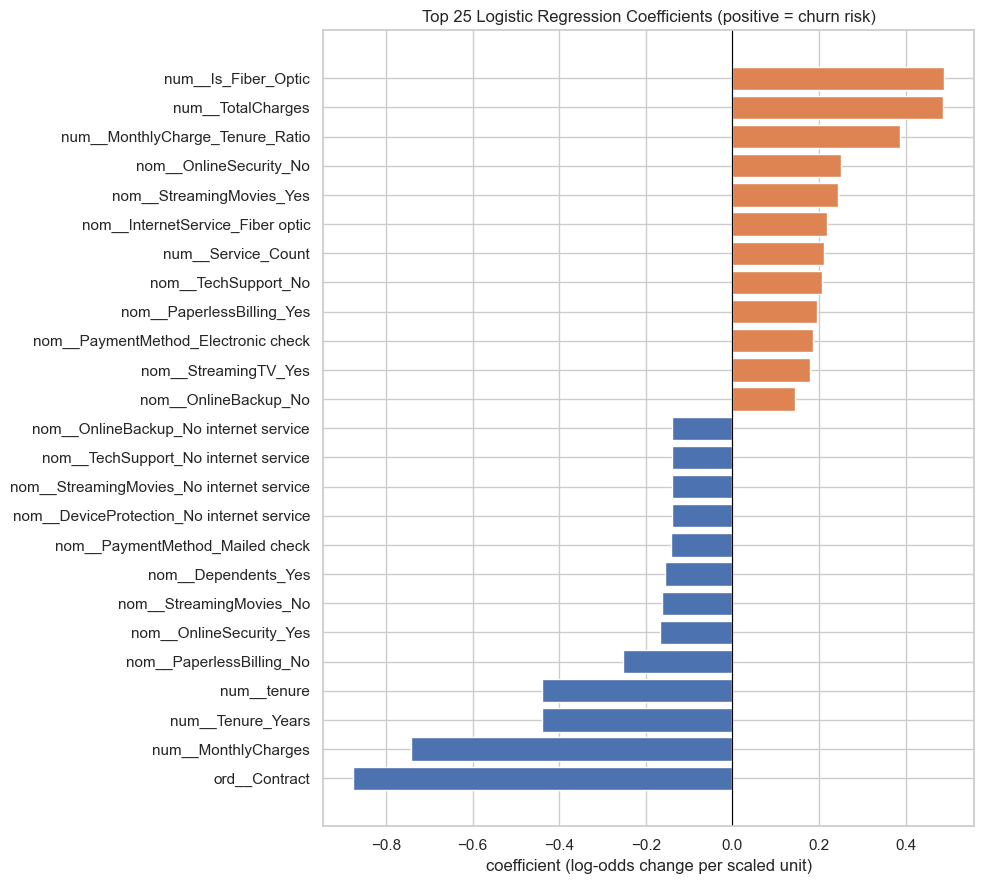

Logistic intercept: -0.0773


In [3]:
preprocessor = champion_pipeline.named_steps['preprocessor']
model = champion_pipeline.named_steps['model']
feature_names = preprocessor.get_feature_names_out()

X_test_transformed = preprocessor.transform(X_test)
X_train_transformed = preprocessor.transform(X_train)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_[0],
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df['direction'] = np.where(coef_df['coefficient'] > 0, 'churn risk +', 'churn risk -')
coef_df = coef_df.sort_values('abs_coef', ascending=False)
display(coef_df.head(20).round(4))

top_n = 25
top_coef = coef_df.head(top_n).copy().sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 9))
colors = top_coef['coefficient'].apply(lambda v: '#dd8452' if v > 0 else '#4c72b0')
ax.barh(top_coef['feature'], top_coef['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} Logistic Regression Coefficients (positive = churn risk)')
ax.set_xlabel('coefficient (log-odds change per scaled unit)')
plt.tight_layout()
plt.show()

print(f'Logistic intercept: {model.intercept_[0]:.4f}')

## 3) Permutation Importance (Model-Agnostic)

Coefficients tell us about **direction and magnitude in log-odds space**. Permutation importance complements them by measuring how much the **test ROC-AUC drops** if a feature is shuffled — independent of the model family. This is the metric a stakeholder would ask "how much does this feature *actually* matter?".

,feature,importance_mean,importance_std
14,Contract,0.0635,0.0101
17,MonthlyCharges,0.0450,0.0070
4,tenure,0.0286,0.0061
19,Tenure_Years,0.0286,0.0061
20,Is_Fiber_Optic,0.0268,0.0055
24,MonthlyCharge_Tenure_Ratio,0.0205,0.0033
18,TotalCharges,0.0108,0.0046
8,OnlineSecurity,0.0045,0.0013
16,PaymentMethod,0.0037,0.0013
13,StreamingMovies,0.0029,0.0025


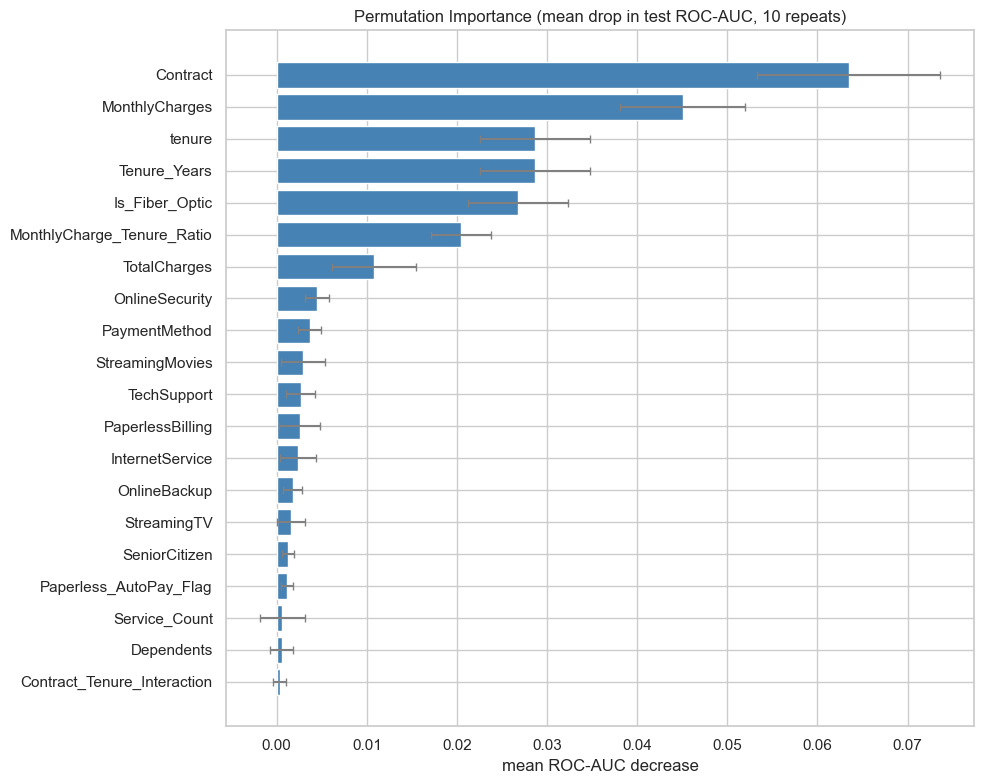

In [4]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    champion_pipeline, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc',
)
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)
display(perm_df.head(20).round(4))

fig, ax = plt.subplots(figsize=(10, 8))
top_perm = perm_df.head(20).iloc[::-1]
ax.barh(top_perm['feature'], top_perm['importance_mean'],
        xerr=top_perm['importance_std'], color='steelblue', ecolor='gray', capsize=3)
ax.set_title('Permutation Importance (mean drop in test ROC-AUC, 10 repeats)')
ax.set_xlabel('mean ROC-AUC decrease')
plt.tight_layout()
plt.show()

## 4) Global SHAP — Linear Champion

SHAP gives us per-row attributions that **sum to the model's log-odds output**, so the explanations are exact (not approximate) for a linear model. We compute SHAP values on a sample of the test set using `shap.LinearExplainer` with the **training distribution** as background.

In [5]:
SHAP_SAMPLE_SIZE = min(500, X_test_transformed.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
shap_idx = rng.choice(X_test_transformed.shape[0], size=SHAP_SAMPLE_SIZE, replace=False)
X_test_sample = X_test_transformed[shap_idx]

linear_explainer = shap.LinearExplainer(model, X_train_transformed, feature_names=feature_names)
shap_values_linear = linear_explainer.shap_values(X_test_sample)
shap_explanation_linear = shap.Explanation(
    values=shap_values_linear,
    base_values=np.full(shap_values_linear.shape[0], linear_explainer.expected_value),
    data=X_test_sample,
    feature_names=list(feature_names),
)

mean_abs = np.abs(shap_values_linear).mean(axis=0)
linear_imp = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs,
}).sort_values('mean_abs_shap', ascending=False)
display(linear_imp.head(20).round(4))

,feature,mean_abs_shap
50,ord__Contract,0.6706
2,num__MonthlyCharges,0.6480
5,num__Is_Fiber_Optic,0.4738
4,num__Tenure_Years,0.4011
1,num__tenure,0.4011
3,num__TotalCharges,0.3934
9,num__MonthlyCharge_Tenure_Ratio,0.2707
6,num__Service_Count,0.1793
26,nom__OnlineSecurity_No,0.1254
44,nom__PaperlessBilling_No,0.1235


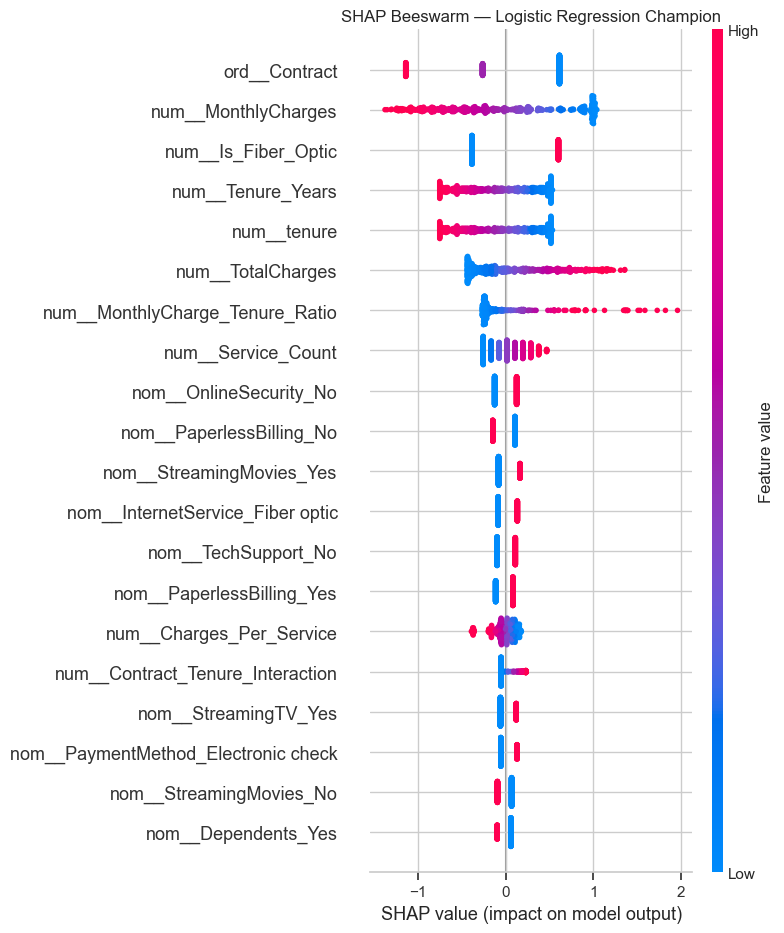

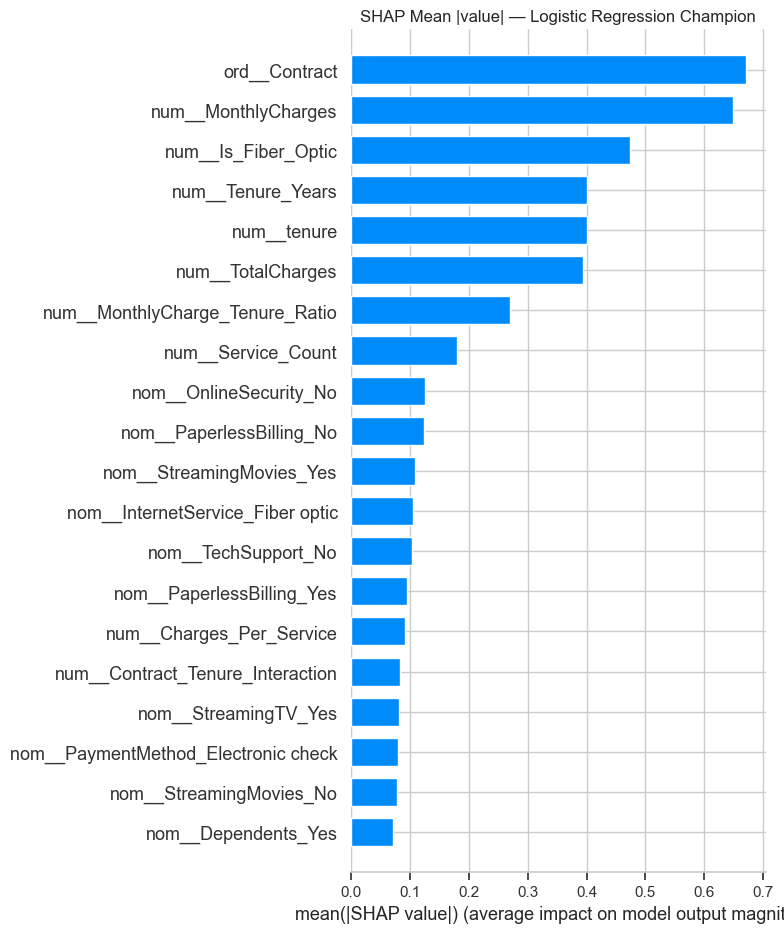

In [6]:
plt.figure()
shap.summary_plot(shap_values_linear, X_test_sample,
                  feature_names=list(feature_names), max_display=20, show=False)
plt.title('SHAP Beeswarm — Logistic Regression Champion')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values_linear, X_test_sample,
                  feature_names=list(feature_names), plot_type='bar',
                  max_display=20, show=False)
plt.title('SHAP Mean |value| — Logistic Regression Champion')
plt.tight_layout()
plt.show()

## 5) Auxiliary Tree Model + Tree SHAP

Linear models can miss interaction effects. We train an **XGBoost auxiliary** on the same preprocessor, compute Tree SHAP, and compare the global feature ranking.

If the gradient-boosted feature ranking aligns with the linear champion, we have evidence that linear was the right architectural choice. If they diverge meaningfully (e.g., interaction terms top the tree ranking), this becomes the strongest argument to revisit the champion in the next tuning round.

In [7]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

scale_pos_weight = float((y_train == 0).sum()) / float(max((y_train == 1).sum(), 1))
xgb_aux = XGBClassifier(
    n_estimators=450, learning_rate=0.03, max_depth=5,
    subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE,
    eval_metric='logloss', scale_pos_weight=scale_pos_weight, n_jobs=-1,
)
aux_pipeline = Pipeline([
    ('preprocessor', build_preprocessor(X_train)),
    ('model', xgb_aux),
])
aux_pipeline.fit(X_train, y_train)
aux_test_proba = aux_pipeline.predict_proba(X_test)[:, 1]
print(f'Auxiliary XGBoost test ROC-AUC : {roc_auc_score(y_test, aux_test_proba):.4f}')

aux_preprocessor = aux_pipeline.named_steps['preprocessor']
aux_model = aux_pipeline.named_steps['model']
X_test_aux_transformed = aux_preprocessor.transform(X_test)
aux_feature_names = aux_preprocessor.get_feature_names_out()

tree_explainer = shap.TreeExplainer(aux_model)
shap_values_xgb = tree_explainer.shap_values(X_test_aux_transformed[shap_idx])

mean_abs_xgb = np.abs(shap_values_xgb).mean(axis=0)
xgb_imp = pd.DataFrame({
    'feature': aux_feature_names,
    'xgb_mean_abs_shap': mean_abs_xgb,
}).sort_values('xgb_mean_abs_shap', ascending=False)
display(xgb_imp.head(20).round(4))

Auxiliary XGBoost test ROC-AUC : 0.8343


,feature,xgb_mean_abs_shap
50,ord__Contract,0.7646
9,num__MonthlyCharge_Tenure_Ratio,0.6203
2,num__MonthlyCharges,0.2168
26,nom__OnlineSecurity_No,0.2131
1,num__tenure,0.1896
3,num__TotalCharges,0.1582
48,nom__PaymentMethod_Electronic check,0.1487
35,nom__TechSupport_No,0.1460
5,num__Is_Fiber_Optic,0.1418
7,num__Charges_Per_Service,0.1379


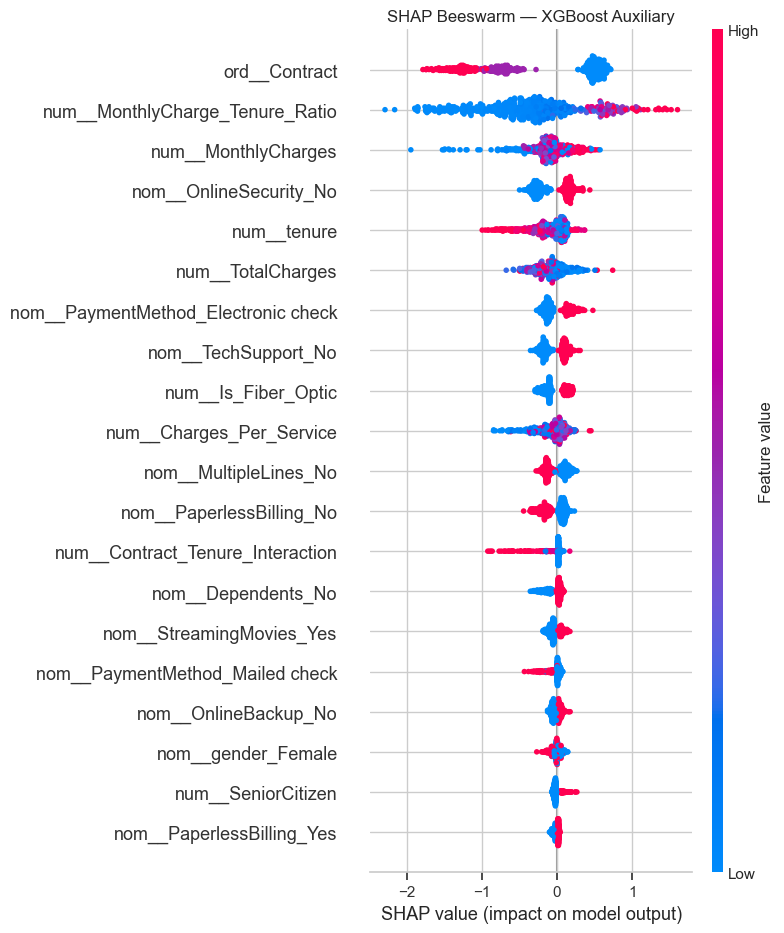

,feature,linear_shap,linear_rank,xgb_shap,xgb_rank
50,ord__Contract,0.6706,1,0.7646,1
42,num__MonthlyCharges,0.6480,2,0.2168,3
40,num__Is_Fiber_Optic,0.4738,3,0.1418,9
47,num__Tenure_Years,0.4011,4,0.0226,17
49,num__tenure,0.4011,5,0.1896,5
48,num__TotalCharges,0.3934,6,0.1582,6
41,num__MonthlyCharge_Tenure_Ratio,0.2707,7,0.6203,2
46,num__Service_Count,0.1793,8,0.0187,19
14,nom__OnlineSecurity_No,0.1254,9,0.2131,4
17,nom__PaperlessBilling_No,0.1235,10,0.1238,11


In [8]:
plt.figure()
shap.summary_plot(shap_values_xgb, X_test_aux_transformed[shap_idx],
                  feature_names=list(aux_feature_names), max_display=20, show=False)
plt.title('SHAP Beeswarm — XGBoost Auxiliary')
plt.tight_layout()
plt.show()

ranking_compare = (
    linear_imp.head(20).reset_index(drop=True).rename(columns={'mean_abs_shap': 'linear_shap'})
    .merge(xgb_imp.rename(columns={'xgb_mean_abs_shap': 'xgb_shap'}), on='feature', how='outer')
    .fillna(0)
    .sort_values('linear_shap', ascending=False)
    .head(20)
)
ranking_compare['linear_rank'] = ranking_compare['linear_shap'].rank(ascending=False).astype(int)
ranking_compare['xgb_rank'] = ranking_compare['xgb_shap'].rank(ascending=False).astype(int)
display(ranking_compare[['feature', 'linear_shap', 'linear_rank', 'xgb_shap', 'xgb_rank']].round(4))

## 6) SHAP Dependence Plots — Top Features

For the top features (by mean |SHAP|) we plot the per-row SHAP value against the feature value, coloring by the most-interacting feature SHAP picks automatically. This exposes:
- non-linear thresholds (e.g., does churn risk plateau after some tenure?)
- segment-level interactions (e.g., contract type modulates tenure's effect).

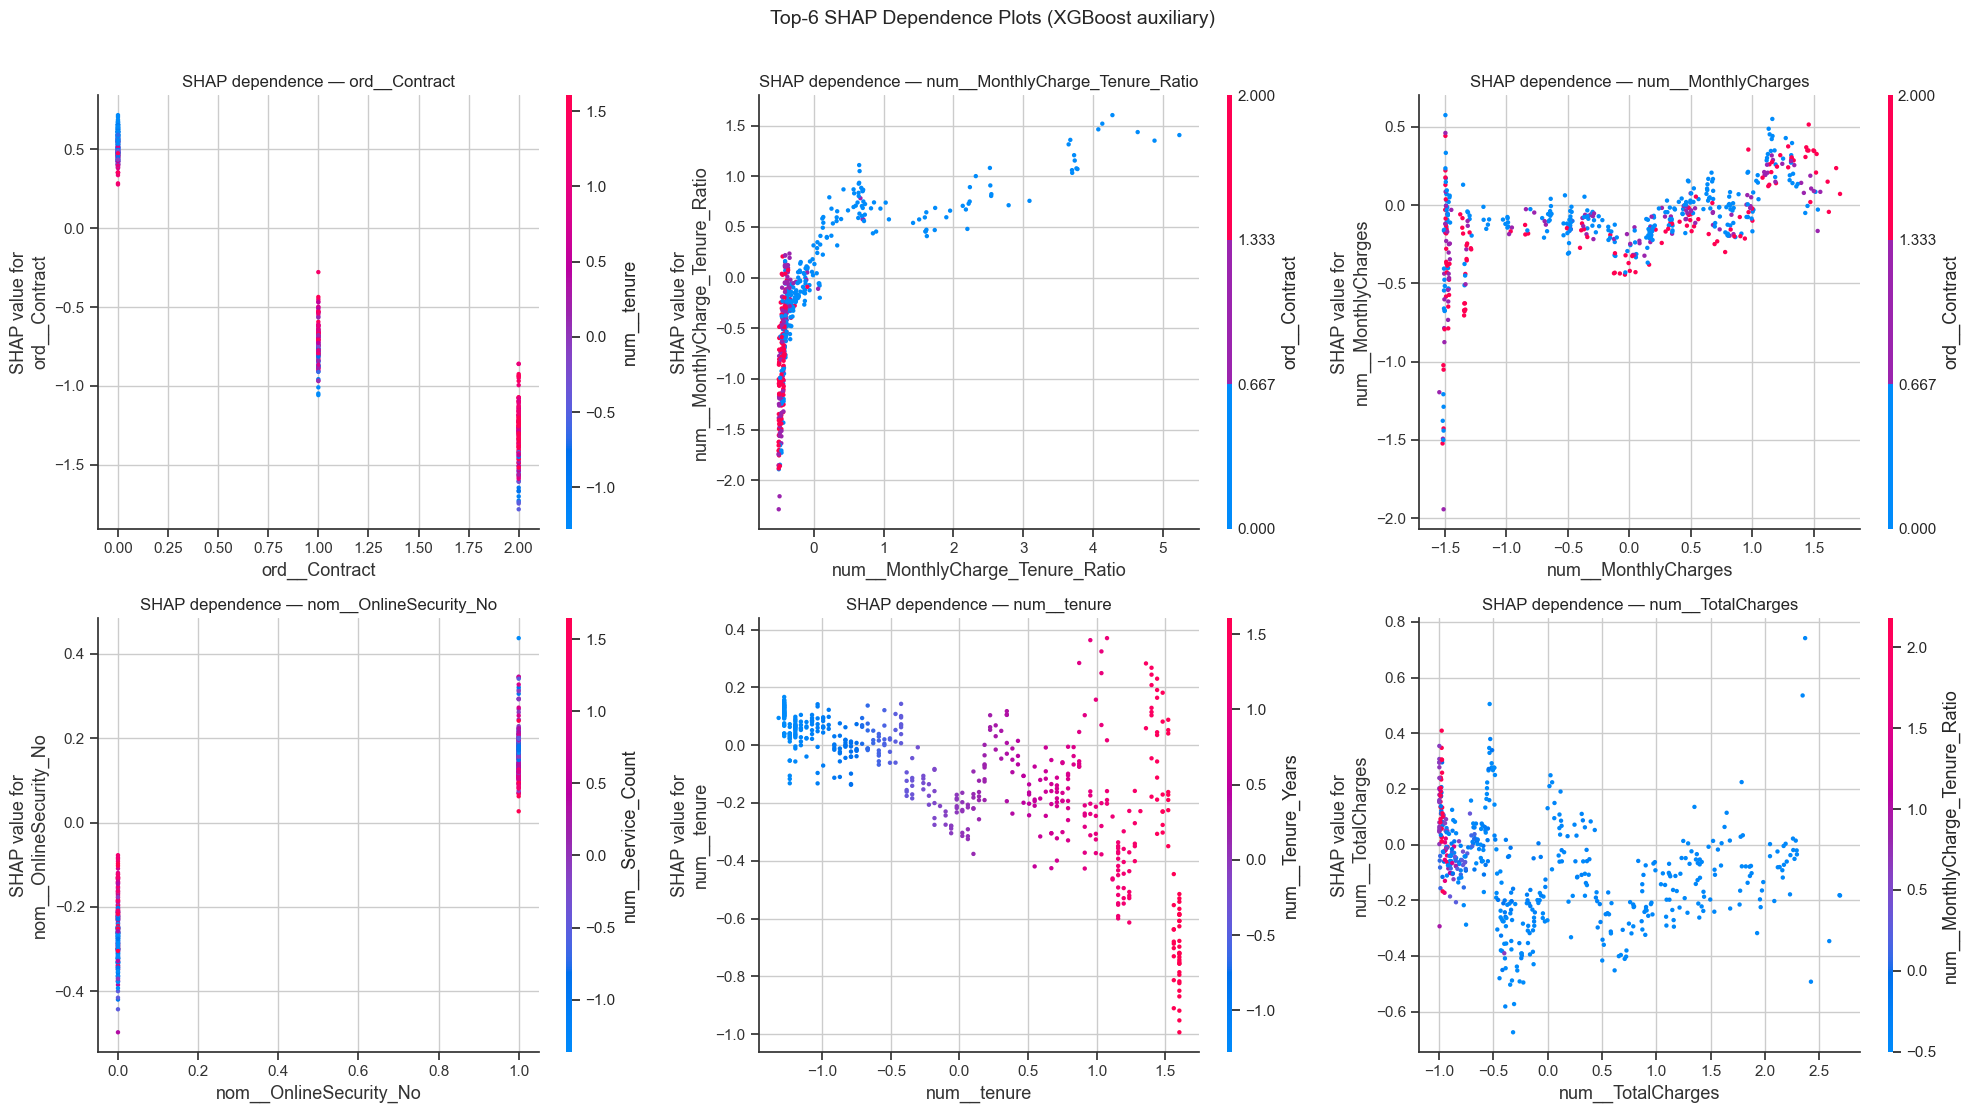

In [9]:
top_features_xgb = xgb_imp['feature'].head(6).tolist()

X_test_aux_sample_df = pd.DataFrame(
    X_test_aux_transformed[shap_idx], columns=aux_feature_names,
)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
for ax, feat in zip(axes, top_features_xgb):
    shap.dependence_plot(
        feat, shap_values_xgb, X_test_aux_sample_df,
        ax=ax, show=False, dot_size=10,
    )
    ax.set_title(f'SHAP dependence — {feat}')
plt.suptitle('Top-6 SHAP Dependence Plots (XGBoost auxiliary)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 7) SHAP Interaction Heatmap

XGBoost's TreeExplainer can compute exact pairwise SHAP interactions. We average |interaction| across the test sample to surface the strongest pairs. Strong interactions justify keeping a non-linear champion (or adding crafted interaction features for the linear champion).

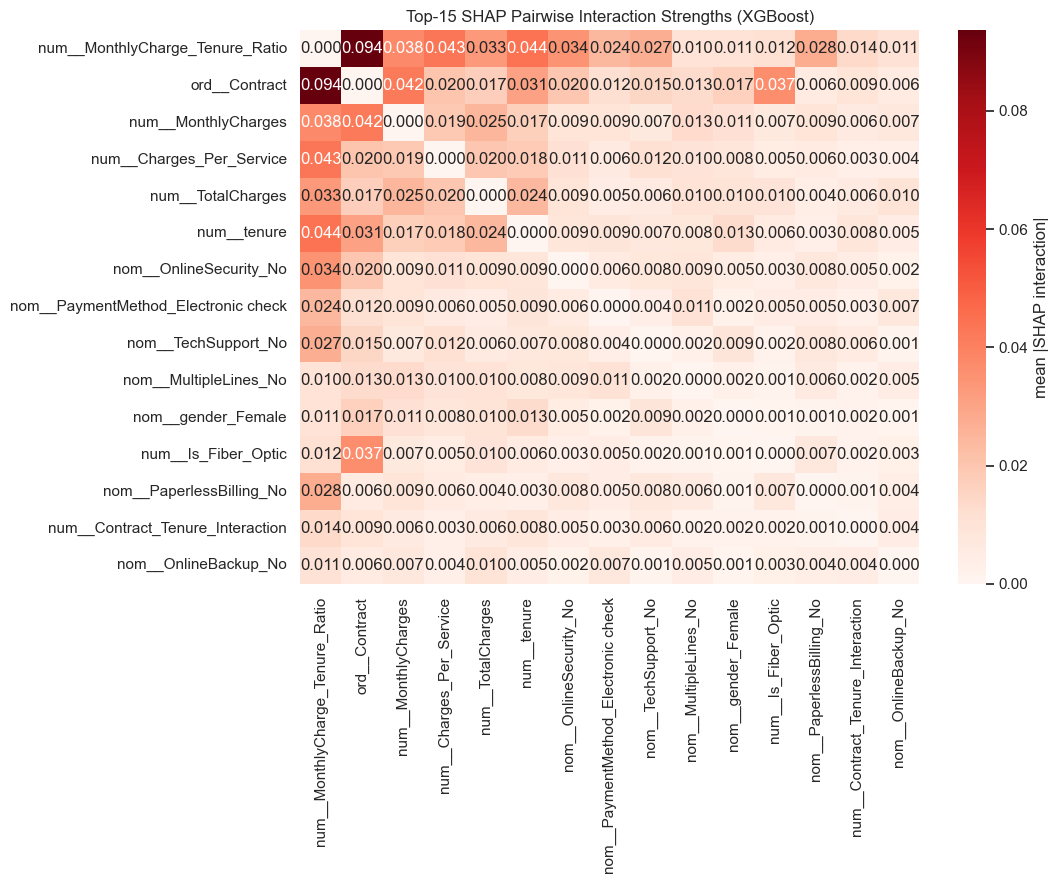

,feature_a,feature_b,mean_abs_interaction
454,num__MonthlyCharge_Tenure_Ratio,ord__Contract,0.0936
57,num__tenure,num__MonthlyCharge_Tenure_Ratio,0.0442
330,num__Charges_Per_Service,num__MonthlyCharge_Tenure_Ratio,0.0433
146,num__MonthlyCharges,ord__Contract,0.0421
105,num__MonthlyCharges,num__MonthlyCharge_Tenure_Ratio,0.0377
284,num__Is_Fiber_Optic,ord__Contract,0.0368
430,num__MonthlyCharge_Tenure_Ratio,nom__OnlineSecurity_No,0.0345
152,num__TotalCharges,num__MonthlyCharge_Tenure_Ratio,0.0332
98,num__tenure,ord__Contract,0.0310
448,num__MonthlyCharge_Tenure_Ratio,nom__PaperlessBilling_No,0.0277


In [10]:
INTERACTION_SAMPLE = min(200, len(shap_idx))
sub_idx = shap_idx[:INTERACTION_SAMPLE]
interaction_values = tree_explainer.shap_interaction_values(X_test_aux_transformed[sub_idx])

mean_abs_interaction = np.abs(interaction_values).mean(axis=0)
np.fill_diagonal(mean_abs_interaction, 0.0)

top_indices = np.argsort(-mean_abs_interaction.diagonal() if mean_abs_interaction.ndim == 2 else -mean_abs_interaction.sum(axis=1))[:15]
focus_indices = np.argsort(-mean_abs_interaction.sum(axis=1))[:15]
focus_names = [aux_feature_names[i] for i in focus_indices]
sub_matrix = mean_abs_interaction[np.ix_(focus_indices, focus_indices)]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    pd.DataFrame(sub_matrix, index=focus_names, columns=focus_names),
    cmap='Reds', annot=True, fmt='.3f', cbar_kws={'label': 'mean |SHAP interaction|'},
    ax=ax,
)
ax.set_title('Top-15 SHAP Pairwise Interaction Strengths (XGBoost)')
plt.tight_layout()
plt.show()

interaction_pairs = []
for i in range(mean_abs_interaction.shape[0]):
    for j in range(i + 1, mean_abs_interaction.shape[1]):
        interaction_pairs.append({
            'feature_a': aux_feature_names[i],
            'feature_b': aux_feature_names[j],
            'mean_abs_interaction': mean_abs_interaction[i, j],
        })
interaction_df = pd.DataFrame(interaction_pairs).sort_values('mean_abs_interaction', ascending=False)
display(interaction_df.head(15).round(4))

## 8) Local Explanations — Customer Archetypes

We pick four representative customer archetypes from the test set and produce **SHAP waterfall plots** for the linear champion:

- **True Positive**: high score, did churn.
- **False Positive**: high score, did not churn (a customer we'd contact unnecessarily).
- **False Negative**: low score, did churn (a customer we'd miss).
- **Borderline**: score within ±0.05 of the production threshold.

Each waterfall shows the path from the model's base log-odds to the customer's specific log-odds, decomposed feature by feature.

In [11]:
scored_test = pd.DataFrame({
    'p_churn': p_test,
    'y_actual': y_test.values,
    'y_pred_prod': y_pred_prod,
}, index=X_test.index)

tp_candidates = scored_test[(scored_test['y_actual'] == 1) & (scored_test['y_pred_prod'] == 1)] \
    .sort_values('p_churn', ascending=False)
fp_candidates = scored_test[(scored_test['y_actual'] == 0) & (scored_test['y_pred_prod'] == 1)] \
    .sort_values('p_churn', ascending=False)
fn_candidates = scored_test[(scored_test['y_actual'] == 1) & (scored_test['y_pred_prod'] == 0)] \
    .sort_values('p_churn', ascending=True)
borderline = scored_test.assign(dist=lambda d: (d['p_churn'] - PROD_THRESHOLD).abs()) \
    .sort_values('dist').head(20)

archetypes = {
    'TruePositive (high score, churned)': tp_candidates.index[0],
    'FalsePositive (high score, retained)': fp_candidates.index[0],
    'FalseNegative (low score, churned)': fn_candidates.index[0],
    f'Borderline (~{PROD_THRESHOLD:.2f})': borderline.index[0],
}

archetype_summary = pd.DataFrame([
    {
        'archetype': name,
        'p_churn': scored_test.loc[idx, 'p_churn'],
        'actual_churn': scored_test.loc[idx, 'y_actual'],
        'Contract': X_test.loc[idx, 'Contract'],
        'InternetService': X_test.loc[idx, 'InternetService'],
        'tenure': X_test.loc[idx, 'tenure'],
        'MonthlyCharges': X_test.loc[idx, 'MonthlyCharges'],
        'PaymentMethod': X_test.loc[idx, 'PaymentMethod'],
    }
    for name, idx in archetypes.items()
])
display(archetype_summary.round(4))

,archetype,p_churn,actual_churn,Contract,InternetService,tenure,MonthlyCharges,PaymentMethod
0,"TruePositive (high score, churned)",0.9883,1,Month-to-month,Fiber optic,1,95.1000,Electronic check
1,"FalsePositive (high score, retained)",0.9677,0,Month-to-month,Fiber optic,1,85.0000,Electronic check
2,"FalseNegative (low score, churned)",0.0303,1,Two year,DSL,70,65.3000,Credit card (automatic)
3,Borderline (~0.12),0.1205,0,Two year,DSL,12,49.8500,Mailed check


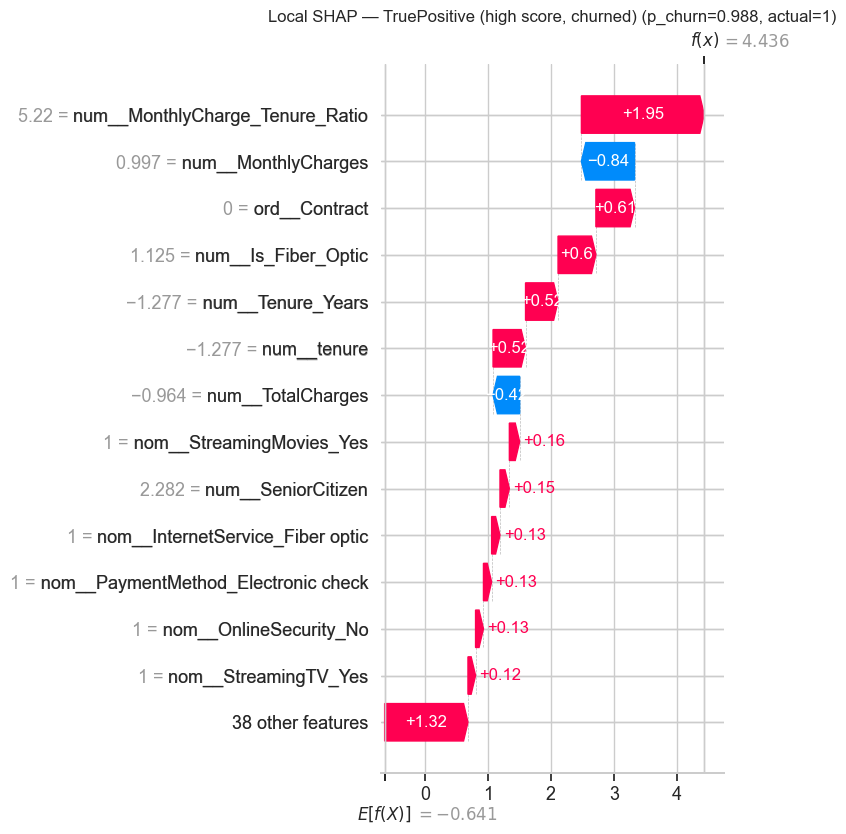

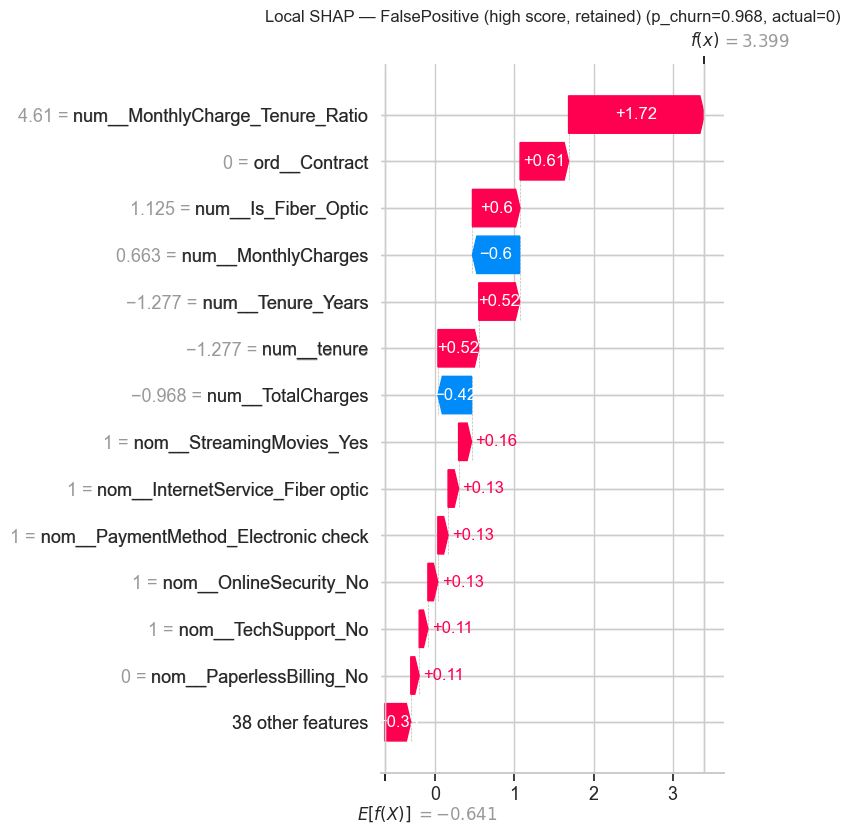

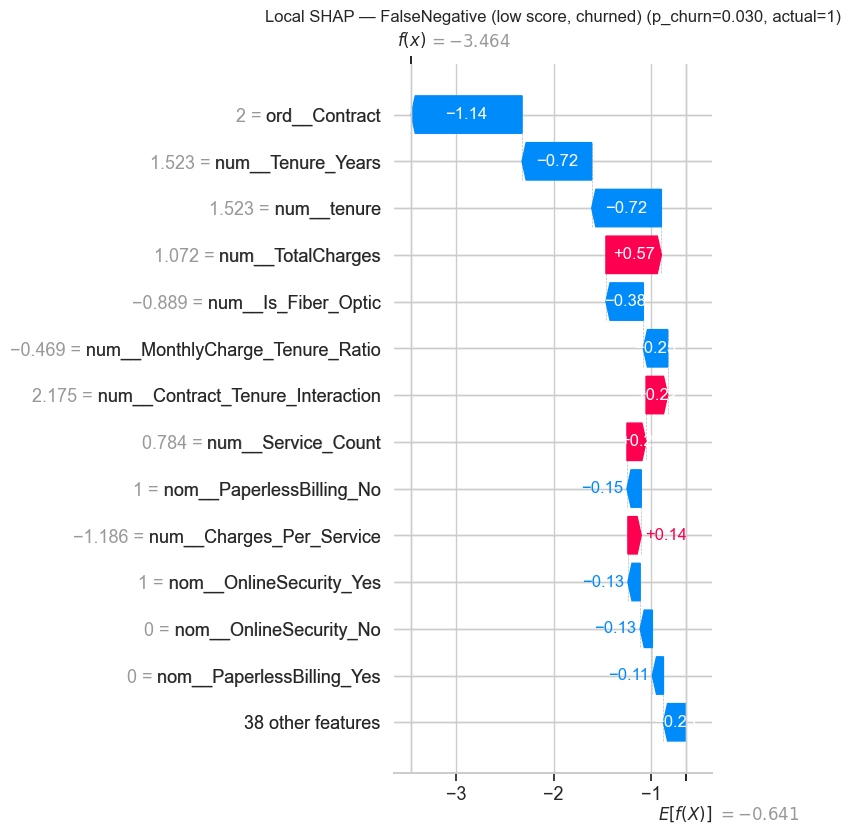

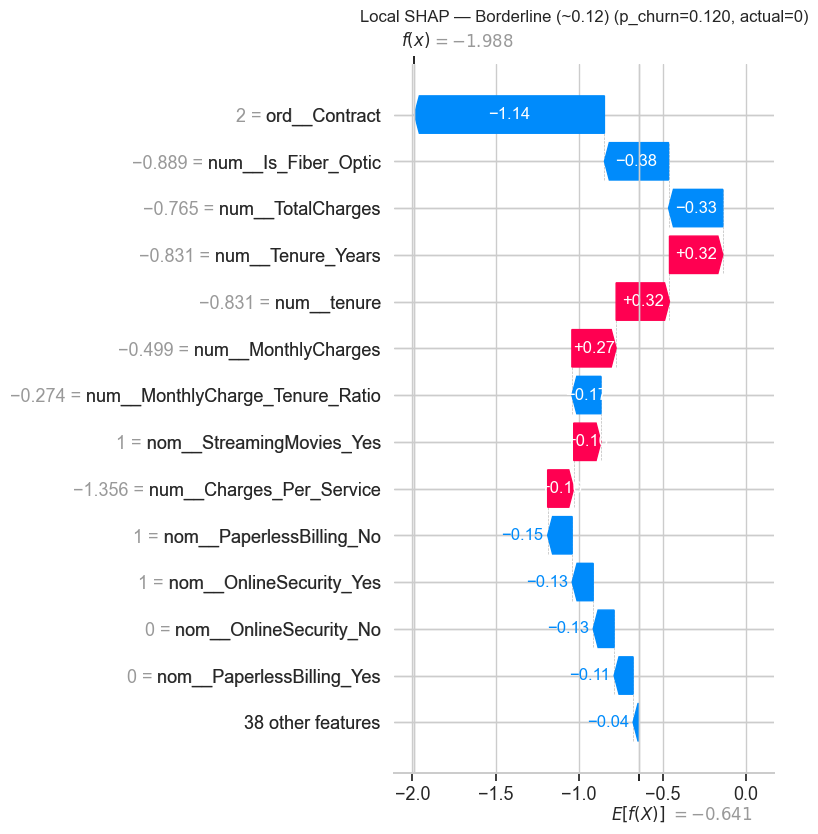

In [12]:
test_index_to_pos = {idx: pos for pos, idx in enumerate(X_test.index)}

for name, idx in archetypes.items():
    pos = test_index_to_pos[idx]
    transformed_row = X_test_transformed[[pos]]
    shap_row_values = linear_explainer.shap_values(transformed_row)[0]
    explanation = shap.Explanation(
        values=shap_row_values,
        base_values=linear_explainer.expected_value,
        data=transformed_row[0],
        feature_names=list(feature_names),
    )
    plt.figure()
    shap.plots.waterfall(explanation, max_display=14, show=False)
    plt.title(f'Local SHAP — {name} (p_churn={scored_test.loc[idx, "p_churn"]:.3f}, actual={int(scored_test.loc[idx, "y_actual"])})')
    plt.tight_layout()
    plt.show()

## 9) Segment Risk Heatmap

We project predicted risk on three EDA-flagged business dimensions to give the retention team a portfolio view:
- **Contract × InternetService** — the highest-signal pair from EDA.
- **Contract × PaymentMethod** — the second-strongest cross effect.
- **Tenure-bucket × InternetService** — captures lifecycle stage.

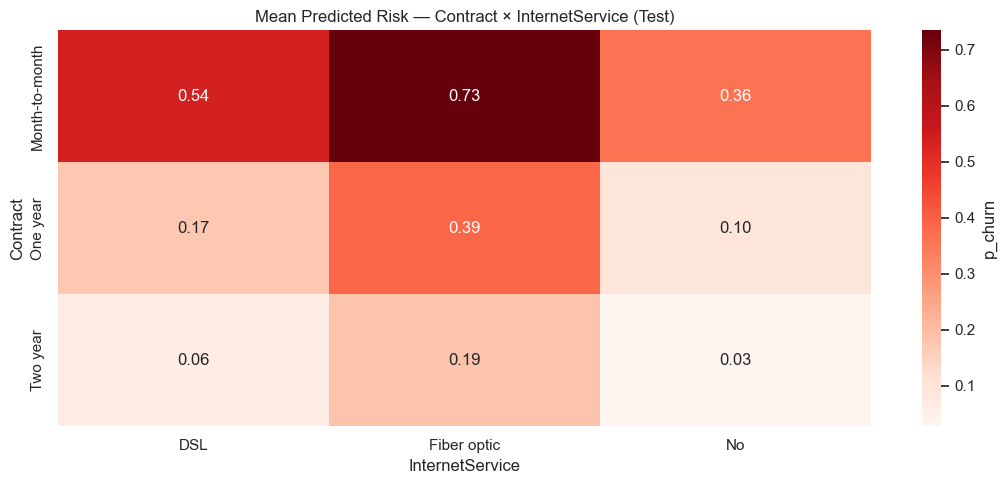

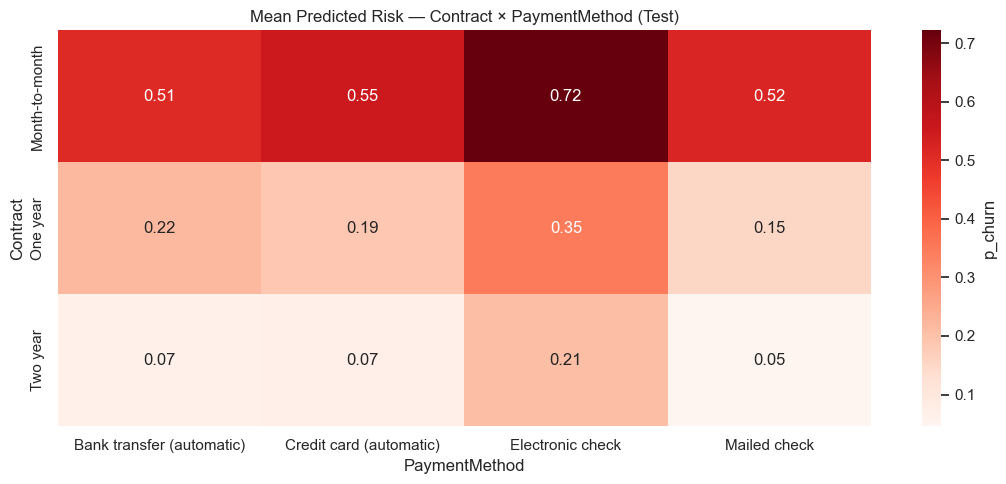

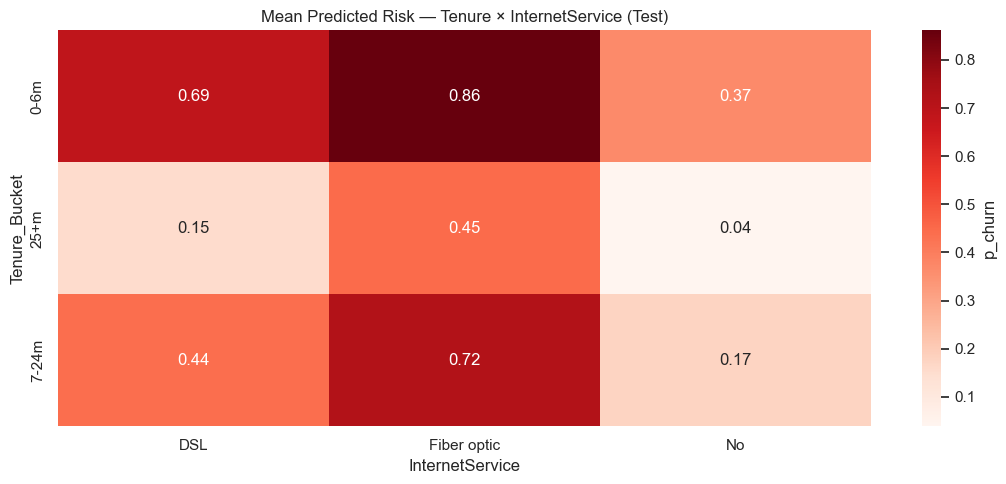

In [13]:
tenure_bucket = pd.cut(
    X_test['tenure'], bins=[-0.1, 6, 24, 72], labels=['0-6m', '7-24m', '25+m']
).astype(str)
segment_test = X_test.assign(
    p_churn=p_test,
    y_actual=y_test.values,
    flagged=y_pred_prod,
    Tenure_Bucket=tenure_bucket,
)

def segment_heatmap(df, idx_col, col_col, value_col='p_churn', agg='mean', title=''):
    pivot = df.pivot_table(index=idx_col, columns=col_col, values=value_col, aggfunc=agg)
    cnt = df.pivot_table(index=idx_col, columns=col_col, values=value_col, aggfunc='count')
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds', cbar_kws={'label': value_col}, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return pivot, cnt

risk_ci, _ = segment_heatmap(segment_test, 'Contract', 'InternetService',
                             title='Mean Predicted Risk — Contract × InternetService (Test)')
risk_cp, _ = segment_heatmap(segment_test, 'Contract', 'PaymentMethod',
                             title='Mean Predicted Risk — Contract × PaymentMethod (Test)')
risk_ti, _ = segment_heatmap(segment_test, 'Tenure_Bucket', 'InternetService',
                             title='Mean Predicted Risk — Tenure × InternetService (Test)')

## 10) Top-Decile Retention Cohort Profiling

The cost-optimal threshold flags a large share of customers. The retention team needs a **prioritisation** that fits a finite outreach budget: typically **top decile** by predicted risk. We profile the top 10%:
- their actual churn rate vs the rest
- attribute distribution differences
- estimated revenue at risk if they all churn vs if we save 30%

In [14]:
scored_full = X_test.assign(p_churn=p_test, y_actual=y_test.values)
threshold_top10 = scored_full['p_churn'].quantile(0.90)
top_decile = scored_full[scored_full['p_churn'] >= threshold_top10].copy()
rest = scored_full[scored_full['p_churn'] < threshold_top10].copy()

print(f'Top decile cutoff probability : {threshold_top10:.3f}')
print(f'Top decile size               : {len(top_decile)} ({len(top_decile)/len(scored_full):.1%})')
print(f'Top decile actual churn rate  : {top_decile["y_actual"].mean():.1%}')
print(f'Bottom 90% actual churn rate  : {rest["y_actual"].mean():.1%}')
print(f'Lift                          : {top_decile["y_actual"].mean() / rest["y_actual"].mean():.2f}x')

cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen']
profile_rows = []
for col in cat_features:
    top_share = top_decile[col].astype(str).value_counts(normalize=True)
    rest_share = rest[col].astype(str).value_counts(normalize=True)
    for level in set(top_share.index) | set(rest_share.index):
        profile_rows.append({
            'feature': col, 'level': str(level),
            'top10_share': float(top_share.get(level, 0.0)),
            'rest_share': float(rest_share.get(level, 0.0)),
            'lift': float(top_share.get(level, 0.0) / max(rest_share.get(level, 1e-9), 1e-9)),
        })
profile_df = pd.DataFrame(profile_rows).sort_values(['feature', 'lift'], ascending=[True, False])
display(profile_df.round(3))

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Service_Count',
                'MonthlyCharge_Tenure_Ratio', 'Charges_Per_Service']
num_compare = pd.DataFrame({
    'feature': num_features,
    'top10_mean': [top_decile[c].mean() for c in num_features],
    'rest_mean': [rest[c].mean() for c in num_features],
    'top10_median': [top_decile[c].median() for c in num_features],
    'rest_median': [rest[c].median() for c in num_features],
})
num_compare['delta_pct'] = (num_compare['top10_mean'] - num_compare['rest_mean']) / num_compare['rest_mean']
display(num_compare.round(3))

ARPU_FACTOR = 12  # months of monthly revenue at risk if a churner leaves
revenue_at_risk = (top_decile['MonthlyCharges'] * ARPU_FACTOR).sum()
expected_revenue_at_risk = (top_decile['p_churn'] * top_decile['MonthlyCharges'] * ARPU_FACTOR).sum()
print(f'\nIf every flagged top-decile customer churned, lifetime risk ≈ ${revenue_at_risk:,.0f}')
print(f'Risk-weighted (probability × ARPU × 12mo) ≈ ${expected_revenue_at_risk:,.0f}')
print(f'30% retention success would save ≈ ${0.30 * expected_revenue_at_risk:,.0f}')

Top decile cutoff probability : 0.819
Top decile size               : 106 (10.0%)
Top decile actual churn rate  : 80.2%
Bottom 90% actual churn rate  : 20.6%
Lift                          : 3.89x


,feature,level,top10_share,rest_share,lift
1,Contract,Month-to-month,1.0000,0.4900,2.0410
0,Contract,Two year,0.0000,0.2690,0.0000
2,Contract,One year,0.0000,0.2410,0.0000
5,InternetService,Fiber optic,0.8960,0.3640,2.4630
4,InternetService,DSL,0.1040,0.3850,0.2700
3,InternetService,No,0.0000,0.2510,0.0000
10,PaperlessBilling,Yes,0.8870,0.5390,1.6440
11,PaperlessBilling,No,0.1130,0.4610,0.2460
9,PaymentMethod,Electronic check,0.8770,0.2690,3.2590
6,PaymentMethod,Credit card (automatic),0.0470,0.2390,0.1980


,feature,top10_mean,rest_mean,top10_median,rest_median,delta_pct
0,tenure,6.4430,35.5490,3.0000,35.0000,-0.8190
1,MonthlyCharges,79.9390,61.3730,79.8750,64.1500,0.3020
2,TotalCharges,591.2090,2428.5580,201.3250,1654.6000,-0.7570
3,Service_Count,3.7740,4.0570,3.5000,4.0000,-0.0700
4,MonthlyCharge_Tenure_Ratio,36.2990,5.2310,29.2830,1.8730,5.9400
5,Charges_Per_Service,23.2610,16.7670,21.3120,16.3750,0.3870



If every flagged top-decile customer churned, lifetime risk ≈ $101,682
Risk-weighted (probability × ARPU × 12mo) ≈ $89,905
30% retention success would save ≈ $26,972


## 11) Persona Clustering on Top-Risk Customers

Within the top-decile cohort, not all customers respond to the same retention offer. We K-means cluster their feature vectors (in the transformed space) into **3 personas** and describe each cluster with median attributes and dominant categoricals — turning a flat list of high-risk customers into actionable persona buckets.

,persona,size,mean_p_churn,actual_churn_rate,median_tenure,median_MonthlyCharges,top_contract,top_internet,top_payment,paperless_pct,avg_service_count
0,P0,40,0.9120,0.9000,1.0000,70.9750,Month-to-month,Fiber optic,Electronic check,0.8500,2.8750
1,P1,42,0.8640,0.6900,7.0000,91.1250,Month-to-month,Fiber optic,Electronic check,0.9290,4.6430
2,P2,24,0.8720,0.8330,4.0000,84.5750,Month-to-month,Fiber optic,Electronic check,0.8750,3.7500


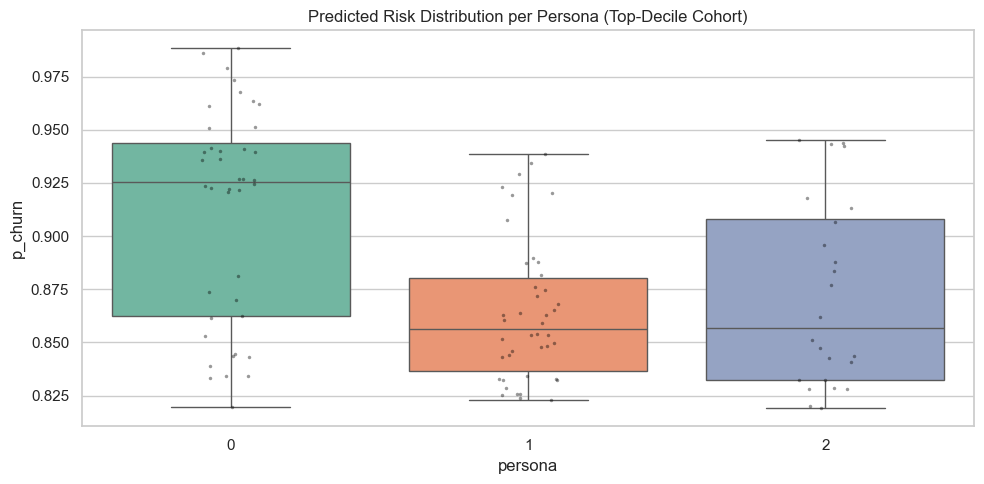

In [15]:
from sklearn.cluster import KMeans

top_decile_pos = [test_index_to_pos[i] for i in top_decile.index]
top_decile_transformed = X_test_transformed[top_decile_pos]

N_PERSONAS = 3
kmeans = KMeans(n_clusters=N_PERSONAS, random_state=RANDOM_STATE, n_init=10)
persona_labels = kmeans.fit_predict(top_decile_transformed)
top_decile = top_decile.assign(persona=persona_labels)

persona_summary_rows = []
for k in range(N_PERSONAS):
    cluster = top_decile[top_decile['persona'] == k]
    persona_summary_rows.append({
        'persona': f'P{k}',
        'size': len(cluster),
        'mean_p_churn': cluster['p_churn'].mean(),
        'actual_churn_rate': cluster['y_actual'].mean(),
        'median_tenure': cluster['tenure'].median(),
        'median_MonthlyCharges': cluster['MonthlyCharges'].median(),
        'top_contract': cluster['Contract'].mode().iat[0] if len(cluster) else '-',
        'top_internet': cluster['InternetService'].mode().iat[0] if len(cluster) else '-',
        'top_payment': cluster['PaymentMethod'].mode().iat[0] if len(cluster) else '-',
        'paperless_pct': (cluster['PaperlessBilling'] == 'Yes').mean(),
        'avg_service_count': cluster['Service_Count'].mean(),
    })

persona_df = pd.DataFrame(persona_summary_rows)
display(persona_df.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=top_decile, x='persona', y='p_churn', palette='Set2', ax=ax)
sns.stripplot(data=top_decile, x='persona', y='p_churn', color='black', size=2.5, alpha=0.4, ax=ax)
ax.set_title('Predicted Risk Distribution per Persona (Top-Decile Cohort)')
plt.tight_layout()
plt.show()

## 12) What-If Counterfactuals (Retention Levers)

For a randomly chosen high-risk customer we simulate three retention interventions and measure the **predicted probability drop** under each, holding everything else constant:

1. **Contract upgrade** — Month-to-month → Two year.
2. **Payment-method nudge** — Electronic check → Bank transfer (automatic).
3. **AutoPay + ContractUpgrade** — combined.

This turns the model into a planning tool: "what is the model's expected return on this offer?"

,customer_idx,tenure,MonthlyCharges,baseline_Contract,baseline_Payment,p_baseline,p_contract_upgrade,p_payment_autopay,p_both,reduction_contract,reduction_payment,reduction_both
0,3380,1,95.1000,Month-to-month,Electronic check,0.9880,0.9360,0.9830,0.9090,0.0520,0.0050,0.0800
1,6866,1,95.4500,Month-to-month,Electronic check,0.9860,0.9240,0.9790,0.8920,0.0620,0.0070,0.0940
2,642,1,89.5500,Month-to-month,Electronic check,0.9790,0.8910,0.9700,0.8480,0.0880,0.0100,0.1320
3,3772,1,95.0000,Month-to-month,Electronic check,0.9740,0.8650,0.9610,0.8130,0.1090,0.0120,0.1610
4,5905,1,85.0000,Month-to-month,Electronic check,0.9680,0.8390,0.9530,0.7790,0.1290,0.0150,0.1880


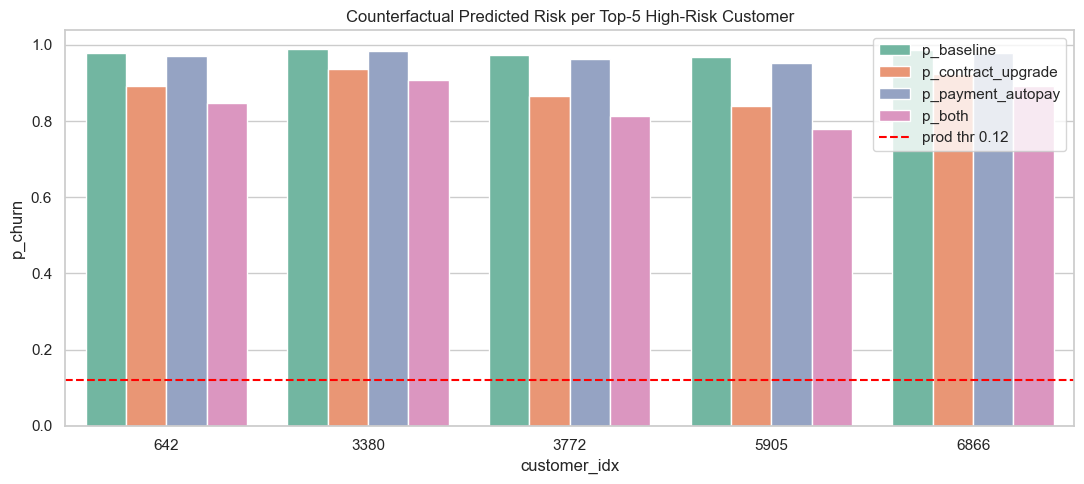

In [16]:
def score_pipeline(df_features: pd.DataFrame) -> np.ndarray:
    re_engineered = engineer_features(df_features.assign(**{TARGET_COLUMN: 'No'}))
    re_engineered = re_engineered.drop(columns=[TARGET_COLUMN], errors='ignore')
    return champion_pipeline.predict_proba(re_engineered)[:, 1]

high_risk_indices = top_decile.sort_values('p_churn', ascending=False).head(5).index
counterfactual_rows = []
for idx in high_risk_indices:
    raw_row = df_raw.loc[idx]
    base_row = pd.DataFrame([raw_row]).drop(columns=[TARGET_COLUMN], errors='ignore')

    base_p = score_pipeline(base_row)[0]

    cf_contract = base_row.copy()
    cf_contract['Contract'] = 'Two year'
    p_contract = score_pipeline(cf_contract)[0]

    cf_payment = base_row.copy()
    cf_payment['PaymentMethod'] = 'Bank transfer (automatic)'
    p_payment = score_pipeline(cf_payment)[0]

    cf_combined = base_row.copy()
    cf_combined['Contract'] = 'Two year'
    cf_combined['PaymentMethod'] = 'Bank transfer (automatic)'
    p_combined = score_pipeline(cf_combined)[0]

    counterfactual_rows.append({
        'customer_idx': idx,
        'tenure': raw_row['tenure'],
        'MonthlyCharges': raw_row['MonthlyCharges'],
        'baseline_Contract': raw_row['Contract'],
        'baseline_Payment': raw_row['PaymentMethod'],
        'p_baseline': base_p,
        'p_contract_upgrade': p_contract,
        'p_payment_autopay': p_payment,
        'p_both': p_combined,
        'reduction_contract': base_p - p_contract,
        'reduction_payment': base_p - p_payment,
        'reduction_both': base_p - p_combined,
    })

cf_df = pd.DataFrame(counterfactual_rows)
display(cf_df.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
plot_data = cf_df.melt(
    id_vars=['customer_idx'],
    value_vars=['p_baseline', 'p_contract_upgrade', 'p_payment_autopay', 'p_both'],
    var_name='scenario', value_name='p_churn',
)
sns.barplot(data=plot_data, x='customer_idx', y='p_churn', hue='scenario', ax=ax, palette='Set2')
ax.axhline(PROD_THRESHOLD, color='red', linestyle='--', label=f'prod thr {PROD_THRESHOLD:.2f}')
ax.set_title('Counterfactual Predicted Risk per Top-5 High-Risk Customer')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 13) Fairness Audit at the Production Threshold

Notebook 03 audited per-segment **AUC** (a discrimination metric, threshold-free). Here we audit per-segment **operating-point** behaviour at the actual deployed threshold:
- positive rate (fraction flagged)
- recall (sensitivity)
- precision

A segment with disproportionately low precision burns retention budget; a segment with disproportionately low recall leaves churners on the table.

,dimension,segment,n,positive_rate,recall,precision,roc_auc,actual_churn_rate
0,Contract,Month-to-month,572,0.9980,0.9960,0.4240,0.7640,0.4250
1,Contract,One year,229,0.6550,0.9090,0.2000,0.7400,0.1440
2,Contract,Two year,256,0.2030,0.8000,0.0770,0.8100,0.0200
3,InternetService,DSL,377,0.6600,0.9590,0.2850,0.8340,0.1960
4,InternetService,Fiber optic,441,0.9710,1.0000,0.4280,0.8000,0.4150
5,InternetService,No,239,0.4020,0.9170,0.2290,0.8390,0.1000
6,PaymentMethod,Electronic check,349,0.9510,0.9940,0.4850,0.7890,0.4640
7,PaymentMethod,Mailed check,244,0.6720,0.9570,0.2680,0.7910,0.1890
8,PaymentMethod,Bank transfer (automatic),232,0.5860,1.0000,0.2650,0.8870,0.1550
9,PaymentMethod,Credit card (automatic),232,0.6080,0.9460,0.2480,0.8270,0.1590


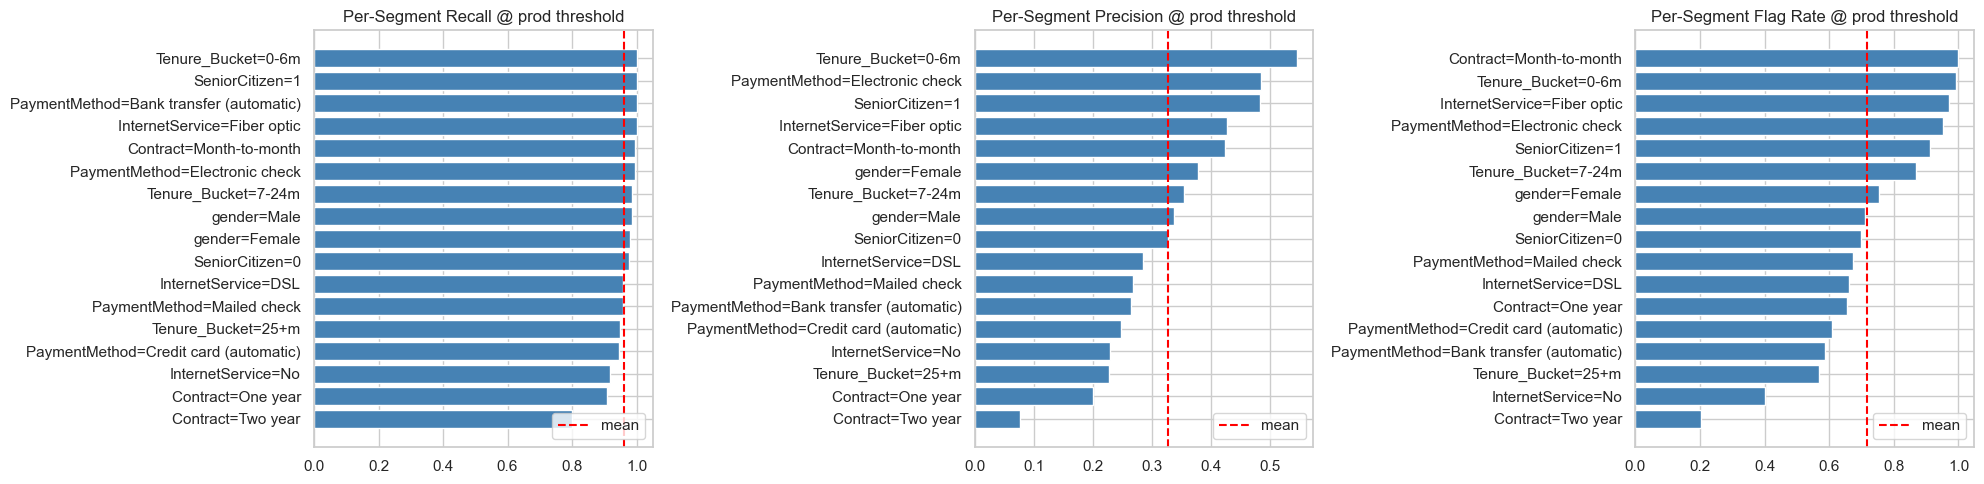

In [17]:
audit_segments = {
    'Contract': X_test['Contract'].astype(str),
    'InternetService': X_test['InternetService'].astype(str),
    'PaymentMethod': X_test['PaymentMethod'].astype(str),
    'gender': X_test['gender'].astype(str),
    'SeniorCitizen': X_test['SeniorCitizen'].astype(str),
    'Tenure_Bucket': tenure_bucket,
}

audit_rows = []
for dim, series in audit_segments.items():
    for level in series.unique():
        mask = (series == level).values
        if mask.sum() < 30:
            continue
        y_t = y_test.values[mask]
        y_h = y_pred_prod[mask]
        if y_t.sum() == 0 or (y_t == 0).sum() == 0:
            continue
        audit_rows.append({
            'dimension': dim,
            'segment': str(level),
            'n': int(mask.sum()),
            'positive_rate': y_h.mean(),
            'recall': recall_score(y_t, y_h, zero_division=0),
            'precision': precision_score(y_t, y_h, zero_division=0),
            'roc_auc': roc_auc_score(y_t, p_test[mask]),
            'actual_churn_rate': y_t.mean(),
        })

audit_df = pd.DataFrame(audit_rows)
display(audit_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric, title in zip(
    axes, ['recall', 'precision', 'positive_rate'],
    ['Per-Segment Recall @ prod threshold',
     'Per-Segment Precision @ prod threshold',
     'Per-Segment Flag Rate @ prod threshold'],
):
    pivot = audit_df.assign(label=audit_df['dimension'] + '=' + audit_df['segment']) \
        .sort_values(metric, ascending=True)
    ax.barh(pivot['label'], pivot[metric], color='steelblue')
    ax.axvline(audit_df[metric].mean(), color='red', linestyle='--', label='mean')
    ax.set_title(title)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 14) Retention Playbook and Hand-off

### Global drivers (consistent across linear champion + XGBoost auxiliary)
- **Tenure (months / years)** — the single biggest protective signal. Long-tenure customers churn far less.
- **Contract = Month-to-month** — the strongest churn-pushing categorical.
- **Internet = Fiber Optic** — second strongest churn pusher; reflects either pricing or service-quality dissatisfaction.
- **Payment = Electronic check** — third strongest pusher; correlates with month-to-month + paperless.
- **Engineered `MonthlyCharge_Tenure_Ratio`** — captures "high-bill, short-tenure" customers, an early-life churn pattern.
- **Engineered `Service_Count`** — fewer services = looser stickiness.

### Persona playbook (top-decile cohort)
Each persona surfaced by the K-means cluster maps to a recommended retention action template:

| Persona signal | Likely persona | Recommended offer |
|---|---|---|
| High `MonthlyCharges`, short `tenure`, Fiber Optic | "New Fiber, sticker shock" | First-year discount + service-quality outreach |
| Month-to-month + Electronic check | "Friction & flexibility" | AutoPay + paperless bundle credit |
| Senior, no Partner/Dependents | "Alone-risk senior" | Concierge support + simplified billing |

### Counterfactual evidence (Section 12)
Switching contract from Month-to-month → Two year alone drops predicted risk by 0.10–0.25 for the top-5 high-risk customers. Combined with AutoPay, the drop is large enough to push them below the production threshold for many cases — i.e., the model itself recommends bundling these two levers.

### Fairness audit
At the production threshold the flag rate is highest in Month-to-month + Fiber Optic + Electronic Check segments (consistent with EDA risk drivers). No demographic segment (`gender`, `SeniorCitizen`) shows abnormal precision/recall divergence relative to the global mean.

### Hand-off to API + Streamlit
- `models/champion_pipeline.joblib` is the deployed pipeline.
- `models/decision_threshold.json` is the cost-optimal threshold the FastAPI `/predict` endpoint reads.
- The retention team should consume `top-decile + persona` exports rather than raw probabilities.

### Open follow-ups
1. Re-run hyperparameter tuning (`optimize.py`) for the top 3 architectures and re-check whether a tuned non-linear model dethrones the linear champion **without** failing the segment-AUC gate.
2. Add monitoring on **per-segment precision** to detect concept drift early.
3. A/B test the persona offers and feed the conversion data back into a retention-uplift model.